In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

from one.api import ONE
from brainbox.population.decode import get_spike_counts_in_bins
from brainbox.io.one import SpikeSortingLoader, SessionLoader
from brainbox.ephys_plots import plot_brain_regions
from brainbox.task.trials import get_event_aligned_raster, get_psth
from iblatlas.atlas import AllenAtlas
from brainbox.behavior.training import compute_performance, plot_psychometric, plot_reaction_time
from brainbox.task.trials import find_trial_ids
from brainbox.io.one import SessionLoader
from brainbox.population.decode import get_spike_counts_in_bins
from pathlib import Path
from brainbox.task.trials import get_event_aligned_raster, get_psth
from brainbox import singlecell
from tqdm.notebook import tqdm
import seaborn as sns

from brainwidemap import bwm_query, load_good_units, load_trials_and_mask, bwm_units

c:\Users\debot\micromamba\envs\info-decom-mirco\Lib\site-packages\scikits\__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)


In [2]:
df_granger = pd.read_csv("../data/processed/granger.csv")
df_decoding_region = pd.read_csv("../data/external/region_info.csv")
df_decoding_session_choice = pd.read_parquet("../data/external/choice_stage2.pqt")
df_decoding_session_stim = pd.read_parquet("../data/external/stimside_stage2.pqt")
df_decoding_session_feedback = pd.read_parquet("../data/external/feedback_stage2.pqt")

In [3]:
important_columns = [
    "Beryl",
    "Beryl.1",
    "# recordings",
    "# neurons",
    "# good neurons",
    "stim_dec",
    "stim_dec_sig",
    "prior_dec_ep",
    "prior_dec_ep_sig",
]

In [4]:
df = df_decoding_region[important_columns]

In [5]:
df_with_signficant_prior = df[df["prior_dec_ep_sig"] == True]

In [6]:
df_with_both = df_with_signficant_prior[df_with_signficant_prior["stim_dec_sig"] == True]

In [7]:
one = ONE(base_url="https://openalyx.internationalbrainlab.org", password="international")

Connected to https://openalyx.internationalbrainlab.org as user "intbrainlab"


In [8]:
bwm_df = bwm_query(one)
unit_df = bwm_units(one)

Loading bwm_query results from fixtures/2023_12_bwm_release.csv
Loading bwm_query results from fixtures/2023_12_bwm_release.csv
d16d0b38d392b18c0ce8b615ec89d60d7c901df2eeb3432986b62130af28ef01


In [9]:
# cross-ref regions, pids, eids and units; should be fast

,Beryl,Beryl.1,# recordings,# neurons,# good neurons,stim_dec,stim_dec_sig,prior_dec_ep,prior_dec_ep_sig
2,MOs,Secondary motor area,60,10023,1293,0.04,1.0,0.052327,1.0
7,SSp-ul,Primary somatosensory area upper limb,16,1761,196,0.05,1.0,0.068949,1.0
20,VISp,Primary visual area,65,8559,880,0.02,1.0,0.019397,1.0
25,ACAd,Anterior cingulate area dorsal part,24,1960,369,0.04,1.0,0.046922,1.0
27,PL,Prelimbic area,21,2165,420,0.03,1.0,0.045498,1.0
76,CP,Caudoputamen,83,25339,2892,0.03,1.0,0.049709,1.0
101,VPM,Ventral posteromedial nucleus of the thalamus,41,7984,1310,0.03,1.0,0.023649,1.0
107,MG,Medial geniculate complex,16,1557,332,0.04,1.0,0.022478,1.0
108,LGd,Dorsal part of the lateral geniculate complex,29,2925,557,0.03,1.0,0.016409,1.0
167,ZI,Zona incerta,50,3180,352,0.03,1.0,0.021970,1.0


In [10]:
# only keep regions of interest

regions_of_interest = df_with_both["Beryl"].unique()

In [11]:
units_regions_of_interest = unit_df[unit_df["Beryl"].isin(regions_of_interest)]

In [12]:
len(units_regions_of_interest["pid"].unique())

# need to download all these pids
# maybe download a fraction locally
# maybe all with ACAd

438

In [13]:
regions_of_interest

array(['MOs', 'SSp-ul', 'VISp', 'ACAd', 'PL', 'CP', 'VPM', 'MG', 'LGd',
       'ZI', 'SNr', 'MRN', 'SCm', 'PAG', 'APN', 'RN', 'PPN', 'PRNc',
       'PRNr', 'GRN', 'IRN', 'PGRN', 'CUL4 5', 'SIM', 'IP'], dtype=object)

In [14]:
eids = units_regions_of_interest["eid"].unique()

In [15]:
import numpy as np

from iblatlas.atlas import BrainRegions
from iblatlas.plots import plot_swanson_vector, plot_scalar_on_slice
import matplotlib as mpl

br = BrainRegions

In [16]:
values = df_with_both["# recordings"].values

In [28]:
values_neurons = df_with_both["# good neurons"].values

In [23]:
def add_cbar(cmap, vmin, vmax, ax, label, cbar_kwargs=dict(), associated=True):
    """
    Add a colorbar to an axis
    :return:
    """
    norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
    if associated:  # whether the axis passed in is stand alone or associated to another plot
        cbar = plt.colorbar(
            mpl.cm.ScalarMappable(norm=norm, cmap=cmap),
            ax=ax,
            orientation="horizontal",
            **cbar_kwargs,
        )
    else:
        cbar = mpl.colorbar.ColorbarBase(ax, cmap=cmap, norm=norm, orientation="horizontal")

    ticks = np.round(np.linspace(vmin, vmax, num=3), 2)
    cbar.set_ticks(ticks)
    cbar.ax.xaxis.set_tick_params(pad=5, labelsize=8)
    cbar.outline.set_visible(False)

    return cbar

c:\Users\debot\micromamba\envs\info-decom-mirco\Lib\site-packages\iblatlas\regions.py:663: RuntimeWarning: All-NaN slice encountered
  all_values = np.nanmedian(v, axis=0)


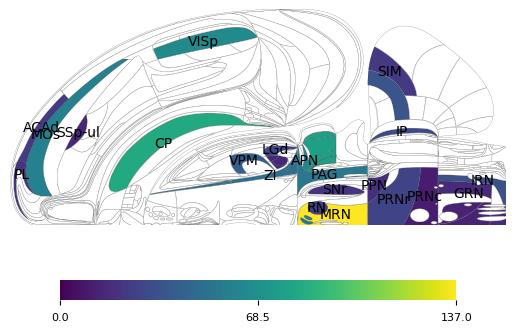

In [26]:
ax = plot_swanson_vector(
    regions_of_interest,
    values,
    hemisphere=None,
    empty_color="white",
    linewidth=0.1,
    mask_color="silver",
    vmin=0,
    vmax=np.max(values),
    annotate=True,
    annotate_list=regions_of_interest,
)

add_cbar(
    cmap="viridis",
    vmin=0,
    vmax=np.max(values),
    ax=ax,
    label="Number of recordings",
    cbar_kwargs={"shrink": 0.8},
    associated=True,
)

c:\Users\debot\micromamba\envs\info-decom-mirco\Lib\site-packages\iblatlas\regions.py:663: RuntimeWarning: All-NaN slice encountered
  all_values = np.nanmedian(v, axis=0)


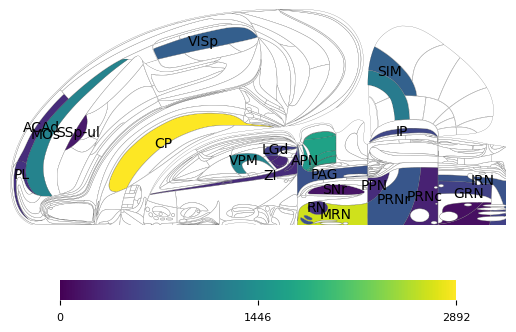

In [29]:
ax = plot_swanson_vector(
    regions_of_interest,
    values_neurons,
    hemisphere=None,
    empty_color="white",
    linewidth=0.1,
    mask_color="silver",
    vmin=0,
    vmax=np.max(values_neurons),
    annotate=True,
    annotate_list=regions_of_interest,
)

add_cbar(
    cmap="viridis",
    vmin=0,
    vmax=np.max(values_neurons),
    ax=ax,
    label="Number of recordings",
    cbar_kwargs={"shrink": 0.8},
    associated=True,
)